<a href="https://colab.research.google.com/github/sasasaee/ml-project/blob/saeera/canteen_classification_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [2]:
url = "https://raw.githubusercontent.com/sasasaee/ml-project/main/data/canteen_dataset_feature_engineered.csv"

df = pd.read_csv(url)

df.head()

,Waste_Weight_kg,Unit_Price_per_kg,Cost_Loss,Day,Month,Weekend,Day_Number,Meal_Dinner,Meal_Lunch,Food_Category_Rice,...,Canteen_Section_D,Day_of_Week_Monday,Day_of_Week_Saturday,Day_of_Week_Sunday,Day_of_Week_Thursday,Day_of_Week_Tuesday,Day_of_Week_Wednesday,Season_Summer,Price_Category_Medium,Price_Category_High
0,1.50,3.0,4.50,30,7,False,49,True,False,False,...,False,False,False,False,False,False,True,False,False,False
1,3.69,2.0,7.38,15,6,True,4,False,False,True,...,False,False,False,True,False,False,False,False,False,False
2,1.54,1.5,2.31,29,7,False,48,False,False,False,...,False,False,False,False,False,True,False,False,False,False
3,1.81,1.5,2.71,17,7,False,36,False,False,False,...,False,False,False,False,True,False,False,False,False,False
4,4.69,2.0,9.38,3,7,False,22,True,False,True,...,True,False,False,False,True,False,False,False,False,False


In [3]:
df.shape

(2600, 24)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2600 entries, 0 to 2599
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Waste_Weight_kg           2600 non-null   float64
 1   Unit_Price_per_kg         2600 non-null   float64
 2   Cost_Loss                 2600 non-null   float64
 3   Day                       2600 non-null   int64  
 4   Month                     2600 non-null   int64  
 5   Weekend                   2600 non-null   bool   
 6   Day_Number                2600 non-null   int64  
 7   Meal_Dinner               2600 non-null   bool   
 8   Meal_Lunch                2600 non-null   bool   
 9   Food_Category_Rice        2600 non-null   bool   
 10  Food_Category_Soup        2600 non-null   bool   
 11  Food_Category_Vegetables  2600 non-null   bool   
 12  Canteen_Section_B         2600 non-null   bool   
 13  Canteen_Section_C         2600 non-null   bool   
 14  Canteen_

##Creating classification target

In [5]:
def classify_waste(weight):
    if weight <= 1.7:
        return "Low"
    elif weight <= 3.5:
        return "Medium"
    else:
        return "High"

df["Waste_Level"] = df["Waste_Weight_kg"].apply(classify_waste)

In [6]:
df["Waste_Level"].value_counts()

,count
Waste_Level,
Medium,960
Low,829
High,811


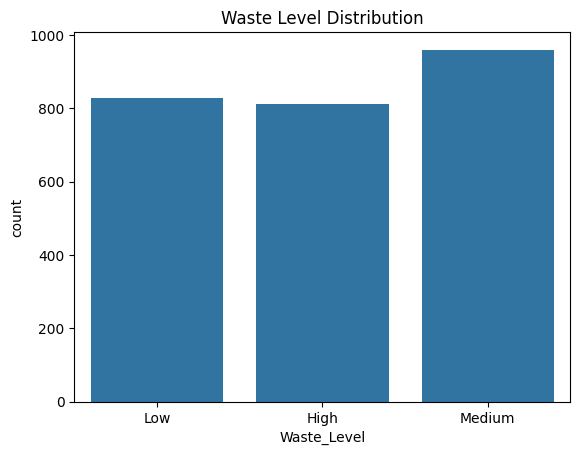

In [7]:
sns.countplot(
    data=df,
    x="Waste_Level"
)

plt.title("Waste Level Distribution")
plt.show()

##Separating Features and Target

In [9]:
X = df.drop(
    columns=[
        "Waste_Weight_kg",
        "Waste_Level"
    ]
)

y = df["Waste_Level"]

print(X.shape)
print(y.shape)

(2600, 23)
(2600,)


In [10]:
X = X.astype(int)
X.head()

,Unit_Price_per_kg,Cost_Loss,Day,Month,Weekend,Day_Number,Meal_Dinner,Meal_Lunch,Food_Category_Rice,Food_Category_Soup,...,Canteen_Section_D,Day_of_Week_Monday,Day_of_Week_Saturday,Day_of_Week_Sunday,Day_of_Week_Thursday,Day_of_Week_Tuesday,Day_of_Week_Wednesday,Season_Summer,Price_Category_Medium,Price_Category_High
0,3,4,30,7,0,49,1,0,0,0,...,0,0,0,0,0,0,1,0,0,0
1,2,7,15,6,1,4,0,0,1,0,...,0,0,0,1,0,0,0,0,0,0
2,1,2,29,7,0,48,0,0,0,1,...,0,0,0,0,0,1,0,0,0,0
3,1,2,17,7,0,36,0,0,0,1,...,0,0,0,0,1,0,0,0,0,0
4,2,9,3,7,0,22,1,0,1,0,...,1,0,0,0,1,0,0,0,0,0


##Encoding Target Labels

In [11]:
encoder = LabelEncoder()
y = encoder.fit_transform(y)
print(encoder.classes_)

['High' 'Low' 'Medium']


##Train-Test Split

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)


print(X_train.shape)
print(X_test.shape)

(1820, 23)
(780, 23)


In [13]:
X = df.drop(
    columns=[
        "Waste_Weight_kg",
        "Cost_Loss",
        "Waste_Level"
    ]
)

##Evaluation Function

In [14]:
def evaluate_classifier(model, name):

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    precision = precision_score(
        y_test,
        y_pred,
        average="weighted"
    )

    recall = recall_score(
        y_test,
        y_pred,
        average="weighted"
    )

    f1 = f1_score(
        y_test,
        y_pred,
        average="weighted"
    )


    print(name)
    print("----------------------")
    print("Accuracy :", round(accuracy,4))
    print("Precision:", round(precision,4))
    print("Recall   :", round(recall,4))
    print("F1 Score :", round(f1,4))

    print("\nClassification Report")
    print(
        classification_report(
            y_test,
            y_pred,
            target_names=encoder.classes_
        )
    )


    return accuracy, precision, recall, f1

##Logistic Regression

In [15]:
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)


lr_model.fit(
    X_train,
    y_train
)


lr_results = evaluate_classifier(
    lr_model,
    "Logistic Regression"
)

Logistic Regression
----------------------
Accuracy : 0.95
Precision: 0.9501
Recall   : 0.95
F1 Score : 0.9499

Classification Report
              precision    recall  f1-score   support

        High       0.94      0.98      0.96       243
         Low       0.97      0.96      0.96       249
      Medium       0.94      0.92      0.93       288

    accuracy                           0.95       780
   macro avg       0.95      0.95      0.95       780
weighted avg       0.95      0.95      0.95       780



##Decision Tree Classifier

In [16]:
from sklearn.model_selection import GridSearchCV

dt_params = {
    "max_depth":[3,5,7,10,None],
    "min_samples_split":[2,5,10],
    "min_samples_leaf":[1,5,10]
}
dt_grid = GridSearchCV(
    DecisionTreeClassifier(
        random_state=42
    ),
    param_grid=dt_params,
    cv=5,
    scoring="f1_weighted",
    n_jobs=-1
)

dt_grid.fit(
    X_train,
    y_train
)
print(dt_grid.best_params_)

dt_model = dt_grid.best_estimator_

{'max_depth': 10, 'min_samples_leaf': 10, 'min_samples_split': 2}


In [17]:
dt_results = evaluate_classifier(
    dt_model,
    "Decision Tree"
)

Decision Tree
----------------------
Accuracy : 0.9321
Precision: 0.9327
Recall   : 0.9321
F1 Score : 0.9315

Classification Report
              precision    recall  f1-score   support

        High       0.94      0.97      0.96       243
         Low       0.91      0.97      0.94       249
      Medium       0.94      0.87      0.90       288

    accuracy                           0.93       780
   macro avg       0.93      0.94      0.93       780
weighted avg       0.93      0.93      0.93       780



##Random Forest Classifier

In [18]:
rf_params = {

    "n_estimators":[100,200],

    "max_depth":[5,10,15],

    "min_samples_split":[2,5,10]

}
rf_grid = GridSearchCV(
    RandomForestClassifier(
        random_state=42
    ),
    param_grid=rf_params,
    cv=5,
    scoring="f1_weighted",
    n_jobs=-1
)


rf_grid.fit(
    X_train,
    y_train
)
print(rf_grid.best_params_)

rf_model = rf_grid.best_estimator_

{'max_depth': 15, 'min_samples_split': 10, 'n_estimators': 200}


In [19]:
rf_results = evaluate_classifier(
    rf_model,
    "Random Forest"
)

Random Forest
----------------------
Accuracy : 0.9359
Precision: 0.9359
Recall   : 0.9359
F1 Score : 0.9358

Classification Report
              precision    recall  f1-score   support

        High       0.94      0.96      0.95       243
         Low       0.96      0.94      0.95       249
      Medium       0.92      0.91      0.91       288

    accuracy                           0.94       780
   macro avg       0.94      0.94      0.94       780
weighted avg       0.94      0.94      0.94       780



##Gradient Boosting Classifier

In [20]:
gb_params = {

    "n_estimators":[100,200],

    "learning_rate":[0.01,0.05,0.1],

    "max_depth":[2,3,5]

}
gb_grid = GridSearchCV(
    GradientBoostingClassifier(
        random_state=42
    ),
    param_grid=gb_params,
    cv=5,
    scoring="f1_weighted",
    n_jobs=-1
)


gb_grid.fit(
    X_train,
    y_train
)
print(gb_grid.best_params_)

gb_model = gb_grid.best_estimator_

{'learning_rate': 0.05, 'max_depth': 2, 'n_estimators': 200}


In [21]:
gb_results = evaluate_classifier(
    gb_model,
    "Gradient Boosting"
)

Gradient Boosting
----------------------
Accuracy : 0.9462
Precision: 0.9469
Recall   : 0.9462
F1 Score : 0.9457

Classification Report
              precision    recall  f1-score   support

        High       0.93      1.00      0.96       243
         Low       0.95      0.96      0.95       249
      Medium       0.96      0.89      0.92       288

    accuracy                           0.95       780
   macro avg       0.95      0.95      0.95       780
weighted avg       0.95      0.95      0.95       780



##AdaBoost Classifier

In [22]:
ada_params = {

    "n_estimators":[50,100,200],

    "learning_rate":[0.01,0.05,0.1]

}
ada_grid = GridSearchCV(
    AdaBoostClassifier(
        random_state=42
    ),
    param_grid=ada_params,
    cv=5,
    scoring="f1_weighted",
    n_jobs=-1
)


ada_grid.fit(
    X_train,
    y_train
)
print(ada_grid.best_params_)

ada_model = ada_grid.best_estimator_

{'learning_rate': 0.1, 'n_estimators': 200}


In [23]:
ada_results = evaluate_classifier(
    ada_model,
    "AdaBoost"
)

AdaBoost
----------------------
Accuracy : 0.5526
Precision: 0.5259
Recall   : 0.5526
F1 Score : 0.4909

Classification Report
              precision    recall  f1-score   support

        High       0.50      0.83      0.62       243
         Low       0.66      0.78      0.71       249
      Medium       0.44      0.12      0.19       288

    accuracy                           0.55       780
   macro avg       0.53      0.58      0.51       780
weighted avg       0.53      0.55      0.49       780



##Comparision

In [24]:
comparison = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting",
        "AdaBoost"
    ],


    "Accuracy":[
        lr_results[0],
        dt_results[0],
        rf_results[0],
        gb_results[0],
        ada_results[0]
    ],


    "Precision":[
        lr_results[1],
        dt_results[1],
        rf_results[1],
        gb_results[1],
        ada_results[1]
    ],


    "Recall":[
        lr_results[2],
        dt_results[2],
        rf_results[2],
        gb_results[2],
        ada_results[2]
    ],


    "F1 Score":[
        lr_results[3],
        dt_results[3],
        rf_results[3],
        gb_results[3],
        ada_results[3]
    ]

})


comparison.sort_values(
    by="F1 Score",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.950000,0.950124,0.950000,0.949877
3,Gradient Boosting,0.946154,0.946929,0.946154,0.945673
2,Random Forest,0.935897,0.935884,0.935897,0.935804
1,Decision Tree,0.932051,0.932743,0.932051,0.931468
4,AdaBoost,0.552564,0.525927,0.552564,0.490853


##Overfitting check

In [27]:
models = {

    "Logistic Regression":lr_model,

    "Decision Tree":dt_model,

    "Random Forest":rf_model,

    "Gradient Boosting":gb_model,

    "AdaBoost":ada_model
}


for name,model in models.items():

    train_accuracy = accuracy_score(
        y_train,
        model.predict(X_train)
    )

    test_accuracy = accuracy_score(
        y_test,
        model.predict(X_test)
    )


    print(name)
    print("Training Accuracy:",round(train_accuracy,4))
    print("Testing Accuracy :",round(test_accuracy,4))
    print()

Logistic Regression
Training Accuracy: 0.9484
Testing Accuracy : 0.95

Decision Tree
Training Accuracy: 0.9566
Testing Accuracy : 0.9321

Random Forest
Training Accuracy: 0.9736
Testing Accuracy : 0.9359

Gradient Boosting
Training Accuracy: 0.9489
Testing Accuracy : 0.9462

AdaBoost
Training Accuracy: 0.578
Testing Accuracy : 0.5526



##Feature Importance